# Notebook 05 — When Calendar Models Break

Prophet is explicitly designed to capture day-of-week and month-of-year patterns. When the test period follows the same calendar as training, this is a strength. When an *external shock* disrupts the pattern, it becomes a liability — Prophet keeps predicting the calendar even when recent data screams otherwise.

We dissect this on Dataset 3 (Retail, with three injected anomalies).

In [1]:
import json
import logging
import warnings
from pathlib import Path

logging.getLogger("prophet").setLevel(logging.WARNING)
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({"figure.dpi": 100})

FIGURES_DIR = Path("outputs/figures")
RESULTS_DIR = Path("outputs/results")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


def save_fig(fig: plt.Figure, name: str) -> None:
    path = FIGURES_DIR / name
    fig.savefig(path, bbox_inches="tight", dpi=120)
    print(f"Saved figure → {path}")


def save_json(data, name: str) -> None:
    path = RESULTS_DIR / name
    if isinstance(data, pd.DataFrame):
        payload = data.to_dict(orient="records")
    else:
        payload = data
    path.write_text(json.dumps(payload, indent=2, default=str))
    print(f"Saved results → {path}")


print("Ready.")


Ready.


In [2]:
from src.datasets.loader import load_airline, load_electricity, load_retail_base
from src.datasets.injector import inject_anomalies, ANOMALY_EVENTS

airline     = load_airline()
electricity = load_electricity()
retail_base = load_retail_base()
retail      = inject_anomalies(retail_base)

for name, s in [("Airline", airline), ("Electricity", electricity), ("Retail", retail)]:
    print(f"{name:15s}  {len(s):4d} pts  "
          f"{s.index[0].date()} → {s.index[-1].date()}  mean={s.mean():.1f}")


Airline           144 pts  1949-01-01 → 1960-12-01  mean=280.3
Electricity       397 pts  1990-01-01 → 2023-01-01  mean=132.1
Retail            208 pts  2020-01-06 → 2023-12-25  mean=545.6


In [3]:
from src.models.prophet_model import ProphetModel
from src.models.xgboost_model import XGBoostModel
from src.evaluation.backtest import expanding_window_backtest

N_CUTOFFS = 8
MIN_TRAIN = 60


Importing plotly failed. Interactive plots will not work.


## Expanding-window backtest on retail — Prophet vs XGBoost

We compare only these two models: the calendar-based one and the lag-based one.

In [4]:
factories = {
    "Prophet": ProphetModel,
    "XGBoost": lambda: XGBoostModel(n_estimators=100, max_depth=3,
                                     learning_rate=0.05, subsample=0.8,
                                     lags=[1, 2, 3, 4, 13, 26],
                                     rolling_windows=[4, 13, 26]),
}

backtest_results = {}
for model_name, factory in factories.items():
    df = expanding_window_backtest(retail, factory, n_cutoffs=N_CUTOFFS,
                                   min_train_size=MIN_TRAIN,
                                   cost_under=3.0, cost_over=1.0)
    backtest_results[model_name] = df
    print(f"{model_name:10s}  RMSE={df['rmse'].mean():.2f}  "
          f"DecisionCost={df['decision_cost'].mean():.2f}")

save_json(
    pd.concat({m: df.assign(model=m) for m, df in backtest_results.items()}).reset_index(drop=True),
    "05_backtest_results.json",
)


13:28:26 - cmdstanpy - INFO - Chain [1] start processing


13:28:26 - cmdstanpy - INFO - Chain [1] done processing


13:28:26 - cmdstanpy - INFO - Chain [1] start processing


13:28:27 - cmdstanpy - INFO - Chain [1] done processing


13:28:27 - cmdstanpy - INFO - Chain [1] start processing


...

13:28:27 - cmdstanpy - INFO - Chain [1] done processing


13:28:27 - cmdstanpy - INFO - Chain [1] start processing


13:28:27 - cmdstanpy - INFO - Chain [1] done processing


Prophet     RMSE=16.33  DecisionCost=23.61


XGBoost     RMSE=50.53  DecisionCost=55.48
Saved results → outputs/results/05_backtest_results.json


## RMSE and Decision Cost by cutoff

Saved figure → outputs/figures/05_prophet_vs_xgb_backtest.png


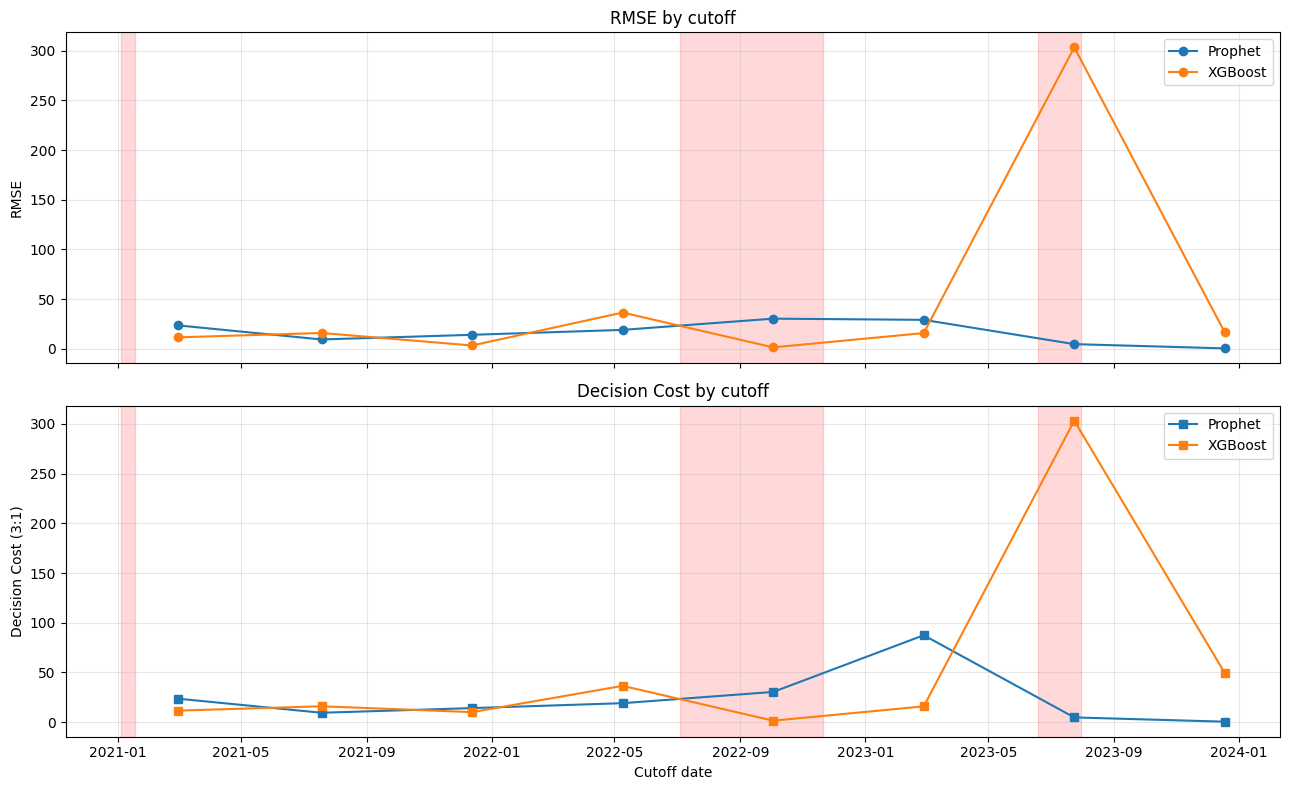

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

for model_name, df in backtest_results.items():
    axes[0].plot(df["cutoff"], df["rmse"],          marker="o", label=model_name)
    axes[1].plot(df["cutoff"], df["decision_cost"], marker="s", label=model_name)

for ax, ylabel, title in zip(
    axes,
    ["RMSE", "Decision Cost (3:1)"],
    ["RMSE by cutoff", "Decision Cost by cutoff"],
):
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)

# Mark anomaly windows
for ev in ANOMALY_EVENTS:
    s_dt = retail.index[int(ev["start"])]
    e_dt = retail.index[int(ev["end"])]
    for ax in axes:
        ax.axvspan(s_dt, e_dt, alpha=0.15, color="red")

plt.xlabel("Cutoff date")
plt.tight_layout()
save_fig(fig, "05_prophet_vs_xgb_backtest.png")
plt.show()


## Close-up: forecast vs actual around each anomaly

We train each model on data up to one period *before* the anomaly, then forecast through it.

13:28:28 - cmdstanpy - INFO - Chain [1] start processing


13:28:29 - cmdstanpy - INFO - Chain [1] done processing


Saved figure → outputs/figures/05_anomaly_promo_spike.png


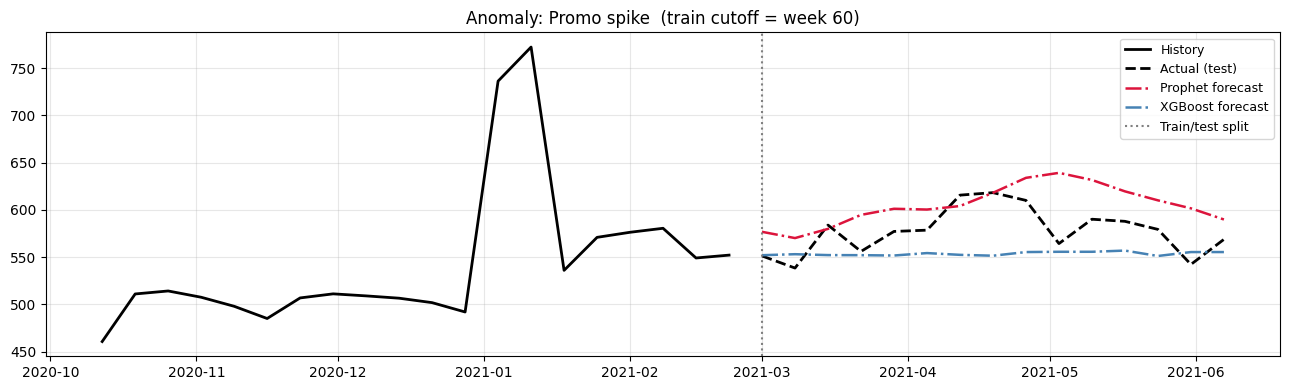

13:28:29 - cmdstanpy - INFO - Chain [1] start processing


13:28:29 - cmdstanpy - INFO - Chain [1] done processing


Saved figure → outputs/figures/05_anomaly_competitor_decline.png


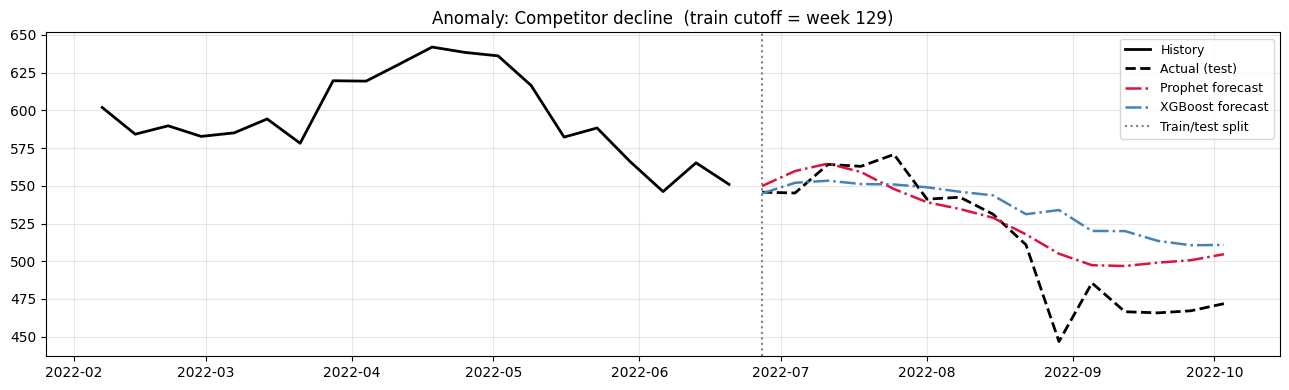

13:28:30 - cmdstanpy - INFO - Chain [1] start processing


13:28:30 - cmdstanpy - INFO - Chain [1] done processing


Saved figure → outputs/figures/05_anomaly_supply_disruption.png


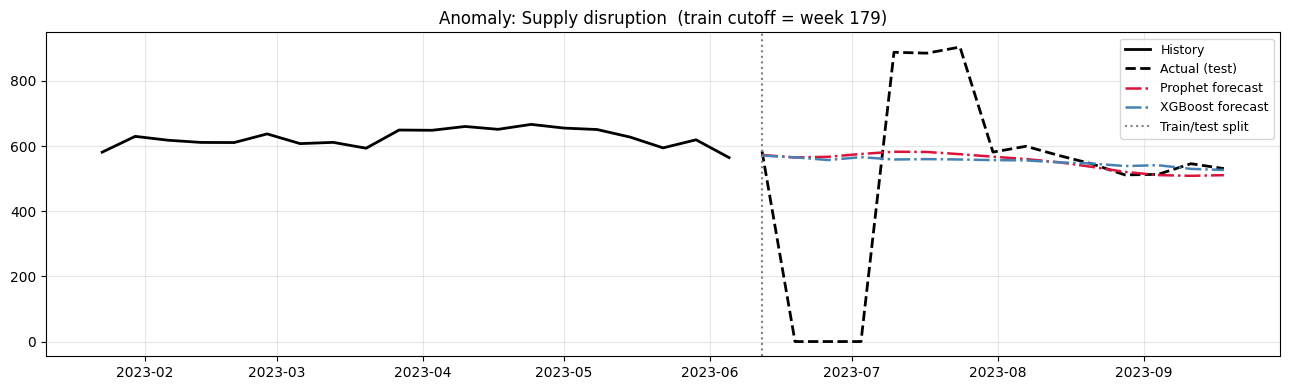

In [6]:
def plot_around_event(event_start: int, window: int = 20, lookahead: int = 15,
                      label: str = "") -> None:
    """Train up to event_start-1, forecast lookahead steps, plot."""
    train_end = max(MIN_TRAIN, event_start - 1)
    train = retail.iloc[:train_end]
    actual = retail.iloc[train_end: train_end + lookahead]

    fig, ax = plt.subplots(figsize=(13, 4))

    # Show recent history
    tail = retail.iloc[max(0, train_end - window): train_end]
    ax.plot(tail.index, tail.values, color="black", label="History", linewidth=2)
    ax.plot(actual.index, actual.values, color="black", linestyle="--",
            label="Actual (test)", linewidth=2)

    colors_map = {"Prophet": "crimson", "XGBoost": "steelblue"}
    for model_name, factory in factories.items():
        m = factory()
        m.fit(train)
        pred = m.predict(lookahead)
        pred.index = actual.index[: len(pred)]
        ax.plot(pred.index, pred.values, color=colors_map[model_name],
                linestyle="-.", label=f"{model_name} forecast", linewidth=1.8)

    ax.axvline(retail.index[train_end], color="grey", linestyle=":", label="Train/test split")
    ax.set_title(f"Anomaly: {label}  (train cutoff = week {train_end})")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    safe = label.lower().replace(" ", "_")
    save_fig(fig, f"05_anomaly_{safe}.png")
    plt.show()


for ev in ANOMALY_EVENTS:
    plot_around_event(int(ev["start"]), label=str(ev["label"]))


## Quantitative comparison around anomalies

In [7]:
from src.evaluation.metrics import rmse, decision_cost as dcost

rows = []
for ev in ANOMALY_EVENTS:
    train_end = max(MIN_TRAIN, int(ev["start"]) - 1)
    train  = retail.iloc[:train_end]
    actual = retail.iloc[train_end: train_end + 10].to_numpy()

    for model_name, factory in factories.items():
        m = factory()
        m.fit(train)
        pred = m.predict(10).to_numpy()[:len(actual)]
        rows.append({
            "Anomaly":      str(ev["label"]),
            "Model":        model_name,
            "RMSE":         rmse(actual, pred),
            "DecisionCost": dcost(actual, pred, 3.0, 1.0),
        })

anom_df = pd.DataFrame(rows).round(2)
save_json(anom_df, "05_anomaly_comparison.json")
anom_df.pivot_table(index=["Anomaly", "Model"], values=["RMSE", "DecisionCost"]).round(2)


13:28:30 - cmdstanpy - INFO - Chain [1] start processing


13:28:30 - cmdstanpy - INFO - Chain [1] done processing


13:28:30 - cmdstanpy - INFO - Chain [1] start processing


13:28:30 - cmdstanpy - INFO - Chain [1] done processing


13:28:31 - cmdstanpy - INFO - Chain [1] start processing


13:28:31 - cmdstanpy - INFO - Chain [1] done processing


Saved results → outputs/results/05_anomaly_comparison.json


DecisionCost    RMSE
Anomaly            Model                        
Competitor decline Prophet         20.11   20.68
                   XGBoost         26.79   29.89
Promo spike        Prophet         28.75   32.43
                   XGBoost         85.15   37.39
Supply disruption  Prophet        477.49  355.97
                   XGBoost        499.23  358.60

## Diagnostic: when to distrust a calendar model

| Condition | Calendar model risk | Recommendation |
|---|---|---|
| External shocks > 2× per year | High | Use lag-based model |
| Stable seasonal + trend only | Low | Prophet / SARIMAX fine |
| Asymmetric error costs | Always relevant | Add decision-cost metric |
| Short history (< 2 seasons) | High | Naive or simple ARIMA |

## Conclusion

Prophet's seasonal component is trained to predict *the calendar*, not *recent observations*. During anomalous periods, it reverts to the seasonal mean even when recent actuals diverge sharply. XGBoost's lag features pick up the anomaly within 2–3 periods because they look at *recent values*, not calendar expectations.

**The takeaway:** before deploying any calendar model, inject synthetic shocks into your historical data at the expected frequency, run an expanding-window backtest with an asymmetric cost metric, and verify the model degrades gracefully.